# Movie Rental Data Warehouse 


| Fact Table | Grain | Key Measures |
|---|---|---|
| `fact_rental` | One row per rental transaction | rental_count, rental_duration, late_return_days |
| `fact_payment` | One row per payment transaction | payment_amount, payment_count |

Shared dimensions: `dim_date`, `dim_customer`, `dim_film`, `dim_store`, `dim_staff`, `dim_location`

## 1. Install Required Libraries

In [1]:
%pip install pandas numpy sqlalchemy pymysql matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

sns.set_theme(style='whitegrid')
print('Libraries imported successfully.')

Libraries imported successfully.


## 4. ETL Setup: Connect to OLTP Source and Target DW

This section performs the complete ETL process from the OLTP movie rental database into the `film_dw` data warehouse. Change `SOURCE_DB` if your OLTP schema name is different, for example `sakila` or `movie_rental`.


In [ ]:
MYSQL_USER     = "root"
MYSQL_PASSWORD = "1111"
MYSQL_HOST     = "127.0.0.1"
MYSQL_PORT     = 3306
SOURCE_DB      = "sakila"     # OLTP/source database name - change if your source DB has another name
TARGET_DB      = "film_dw"    # Data warehouse database name

from sqlalchemy import create_engine, text

# Server connection: used to create the target data warehouse database if it does not exist
server_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/"
)

with server_engine.begin() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {TARGET_DB}"))

# Source OLTP connection
src_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{SOURCE_DB}"
)

# Target DW connection
dw_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{TARGET_DB}"
)

print("Connection settings are ready.")
print("Source OLTP database:", SOURCE_DB)
print("Target DW database:", TARGET_DB)



## 5. Extract Data from OLTP Tables

The extract step reads only the OLTP tables needed for the dimensional model: rental, payment, customer, film, inventory, store, staff, address, city, country, category, film_category, language, actor, and film_actor.


In [ ]:
tables = [
    "rental", "payment", "customer", "film", "inventory", "store", "staff",
    "address", "city", "country", "category", "film_category", "language",
    "actor", "film_actor"
]

oltp = {}
for table in tables:
    oltp[table] = pd.read_sql(f"SELECT * FROM {table}", src_engine)
    print(f"Extracted {table:<15}: {len(oltp[table])} rows")


## 5.1 Transform Dimensions

Dimensions are cleaned, joined, and assigned warehouse surrogate keys. Operational IDs are kept as natural/source keys for traceability.


In [ ]:
def add_surrogate_key(df, key_name):
    df = df.reset_index(drop=True).copy()
    df.insert(0, key_name, range(1, len(df) + 1))
    return df

def clean_text(series):
    return series.astype(str).str.strip()

# ----------------------
# dim_location
# ----------------------
address = oltp["address"].merge(oltp["city"], on="city_id", how="left") \
                         .merge(oltp["country"], on="country_id", how="left")

dim_location = address[["address_id", "address", "district", "city", "country", "postal_code", "phone"]].copy()
for col in ["address", "district", "city", "country", "postal_code", "phone"]:
    dim_location[col] = clean_text(dim_location[col]).replace("nan", np.nan)
dim_location = add_surrogate_key(dim_location, "location_key")

# ----------------------
# dim_customer
# ----------------------
customer = oltp["customer"].merge(
    dim_location[["location_key", "address_id", "city", "country"]], on="address_id", how="left"
)
customer["full_name"] = clean_text(customer["first_name"]) + " " + clean_text(customer["last_name"])

dim_customer = customer[[
    "customer_id", "store_id", "first_name", "last_name", "full_name", "email", "active",
    "create_date", "address_id", "location_key", "city", "country"
]].copy()
dim_customer = add_surrogate_key(dim_customer, "customer_key")

# ----------------------
# dim_staff
# ----------------------
staff = oltp["staff"].merge(
    dim_location[["location_key", "address_id", "city", "country"]], on="address_id", how="left"
)
staff["full_name"] = clean_text(staff["first_name"]) + " " + clean_text(staff["last_name"])

dim_staff = staff[[
    "staff_id", "store_id", "first_name", "last_name", "full_name", "email", "active",
    "address_id", "location_key", "city", "country"
]].copy()
dim_staff = add_surrogate_key(dim_staff, "staff_key")

# ----------------------
# dim_store
# ----------------------
store = oltp["store"].merge(
    dim_location[["location_key", "address_id", "address", "city", "country"]], on="address_id", how="left"
)
manager_names = dim_staff[["staff_id", "full_name"]].rename(columns={"staff_id": "manager_staff_id", "full_name": "manager_name"})
store = store.merge(manager_names, on="manager_staff_id", how="left")

dim_store = store[[
    "store_id", "manager_staff_id", "manager_name", "address_id", "location_key", "address", "city", "country"
]].copy()
dim_store = add_surrogate_key(dim_store, "store_key")

# ----------------------
# dim_film
# ----------------------
film_category = oltp["film_category"].merge(oltp["category"], on="category_id", how="left")
film_categories = film_category.groupby("film_id", as_index=False)["name"].agg(lambda x: ", ".join(sorted(set(x))))
film_categories = film_categories.rename(columns={"name": "category_name"})

film_actor = oltp["film_actor"].merge(oltp["actor"], on="actor_id", how="left")
film_actor["actor_name"] = clean_text(film_actor["first_name"]) + " " + clean_text(film_actor["last_name"])
film_actors = film_actor.groupby("film_id", as_index=False)["actor_name"].agg(lambda x: ", ".join(sorted(set(x))))
film_actors = film_actors.rename(columns={"actor_name": "actors"})

film = oltp["film"].merge(oltp["language"], on="language_id", how="left") \
                   .merge(film_categories, on="film_id", how="left") \
                   .merge(film_actors, on="film_id", how="left")

dim_film = film[[
    "film_id", "title", "description", "release_year", "rental_duration", "rental_rate",
    "length", "replacement_cost", "rating", "special_features", "name", "category_name", "actors"
]].copy()
dim_film = dim_film.rename(columns={"name": "language_name"})
dim_film["category_name"] = dim_film["category_name"].fillna("Unknown")
dim_film["actors"] = dim_film["actors"].fillna("Unknown")
dim_film = add_surrogate_key(dim_film, "film_key")

# ----------------------
# dim_date
# ----------------------
date_values = []
for table_name, date_cols in {
    "rental": ["rental_date", "return_date"],
    "payment": ["payment_date"],
    "customer": ["create_date"]
}.items():
    for col in date_cols:
        date_values.append(pd.to_datetime(oltp[table_name][col], errors="coerce").dt.date)

all_dates = pd.concat(date_values).dropna().drop_duplicates().sort_values().reset_index(drop=True)
dim_date = pd.DataFrame({"full_date": pd.to_datetime(all_dates)})
dim_date["date_key"] = dim_date["full_date"].dt.strftime("%Y%m%d").astype(int)
dim_date["day"] = dim_date["full_date"].dt.day
dim_date["month"] = dim_date["full_date"].dt.month
dim_date["month_name"] = dim_date["full_date"].dt.month_name()
dim_date["quarter"] = dim_date["full_date"].dt.quarter
dim_date["year"] = dim_date["full_date"].dt.year
dim_date["day_name"] = dim_date["full_date"].dt.day_name()
dim_date = dim_date[["date_key", "full_date", "day", "month", "month_name", "quarter", "year", "day_name"]]

print("Dimensions created:")
for name, df in {
    "dim_date": dim_date,
    "dim_location": dim_location,
    "dim_customer": dim_customer,
    "dim_store": dim_store,
    "dim_staff": dim_staff,
    "dim_film": dim_film,
}.items():
    print(f"{name:<15}: {len(df)} rows")


## 5.2 Transform Fact Tables

Facts are built at the transaction grain. `fact_rental` has one row per rental transaction, and `fact_payment` has one row per payment transaction.


In [ ]:
# Lookup tables from natural/source IDs to surrogate keys
customer_lu = dim_customer[["customer_id", "customer_key"]]
film_lu     = dim_film[["film_id", "film_key", "rental_duration"]]
store_lu    = dim_store[["store_id", "store_key"]]
staff_lu    = dim_staff[["staff_id", "staff_key"]]
inv_lu      = oltp["inventory"][["inventory_id", "film_id", "store_id"]]

def to_date_key(series):
    return pd.to_datetime(series, errors="coerce").dt.strftime("%Y%m%d").astype("Int64")

# ----------------------
# fact_rental
# ----------------------
rental = oltp["rental"].copy()
rental = rental.merge(inv_lu, on="inventory_id", how="left") \
               .merge(customer_lu, on="customer_id", how="left") \
               .merge(film_lu, on="film_id", how="left") \
               .merge(store_lu, on="store_id", how="left") \
               .merge(staff_lu, on="staff_id", how="left")

rental["rental_date_key"] = to_date_key(rental["rental_date"])
rental["return_date_key"] = to_date_key(rental["return_date"])
rental["actual_rental_duration"] = (
    pd.to_datetime(rental["return_date"], errors="coerce") - pd.to_datetime(rental["rental_date"], errors="coerce")
).dt.days
rental["late_return_days"] = (rental["actual_rental_duration"] - rental["rental_duration"]).clip(lower=0)
rental["rental_count"] = 1

fact_rental = rental[[
    "rental_id", "rental_date_key", "return_date_key", "customer_key", "film_key",
    "store_key", "staff_key", "rental_count", "actual_rental_duration", "late_return_days"
]].copy()
fact_rental = fact_rental.rename(columns={"actual_rental_duration": "rental_duration"})
fact_rental = add_surrogate_key(fact_rental, "rental_fact_key")

# ----------------------
# fact_payment
# ----------------------
payment = oltp["payment"].copy()
payment = payment.merge(oltp["rental"][["rental_id", "inventory_id"]], on="rental_id", how="left") \
                 .merge(inv_lu, on="inventory_id", how="left") \
                 .merge(customer_lu, on="customer_id", how="left") \
                 .merge(film_lu[["film_id", "film_key"]], on="film_id", how="left") \
                 .merge(store_lu, on="store_id", how="left") \
                 .merge(staff_lu, on="staff_id", how="left")

payment["payment_date_key"] = to_date_key(payment["payment_date"])
payment["payment_amount"] = pd.to_numeric(payment["amount"], errors="coerce").fillna(0)
payment["payment_count"] = 1

fact_payment = payment[[
    "payment_id", "rental_id", "payment_date_key", "customer_key", "film_key",
    "store_key", "staff_key", "payment_amount", "payment_count"
]].copy()
fact_payment = add_surrogate_key(fact_payment, "payment_fact_key")

print("Fact tables created:")
print("fact_rental :", len(fact_rental), "rows")
print("fact_payment:", len(fact_payment), "rows")


## 5.3 Data Quality Checks Before Loading

These checks verify that fact records have valid dimension keys and that measures are logical before loading into the data warehouse.


In [ ]:
print("=== Pre-Load Data Quality Checks ===")

preload_checks = {
    "fact_rental missing customer_key": fact_rental["customer_key"].isna().sum(),
    "fact_rental missing film_key": fact_rental["film_key"].isna().sum(),
    "fact_rental missing store_key": fact_rental["store_key"].isna().sum(),
    "fact_rental missing staff_key": fact_rental["staff_key"].isna().sum(),
    "fact_payment missing customer_key": fact_payment["customer_key"].isna().sum(),
    "fact_payment missing film_key": fact_payment["film_key"].isna().sum(),
    "fact_payment missing store_key": fact_payment["store_key"].isna().sum(),
    "fact_payment missing staff_key": fact_payment["staff_key"].isna().sum(),
    "fact_payment negative amount": (fact_payment["payment_amount"] < 0).sum(),
    "duplicate rental_id": fact_rental["rental_id"].duplicated().sum(),
    "duplicate payment_id": fact_payment["payment_id"].duplicated().sum(),
}

for check, count in preload_checks.items():
    status = "PASS" if count == 0 else "CHECK"
    print(f"[{status}] {check:<40} {count}")


## 5.4 Load Dimensions and Facts into `film_dw`

The load step inserts dimensions first, then facts, because fact tables depend on dimension surrogate keys.


In [ ]:
load_order = [
    ("dim_date", dim_date),
    ("dim_location", dim_location),
    ("dim_customer", dim_customer),
    ("dim_store", dim_store),
    ("dim_staff", dim_staff),
    ("dim_film", dim_film),
    ("fact_rental", fact_rental),
    ("fact_payment", fact_payment),
]

with dw_engine.begin() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS = 0"))
    for table_name, df in load_order:
        df.to_sql(table_name, con=conn, if_exists="replace", index=False)
        print(f"Loaded {table_name:<15}: {len(df)} rows")
    conn.execute(text("SET FOREIGN_KEY_CHECKS = 1"))

print("ETL finished successfully. The data warehouse tables are ready for analysis.")


## 6. dim_date

In [5]:
dim_date = pd.read_sql("SELECT * FROM dim_date", dw_engine)
display(dim_date.head())
print("dim_date rows:", len(dim_date))

,date_key,full_date,day,month,month_name,quarter_num,year,weekday_name,weekend_flag
0,19000101,1900-01-01,1,1,January,1,1900,Monday,N
1,20050524,2005-05-24,24,5,May,2,2005,Tuesday,N
2,20050525,2005-05-25,25,5,May,2,2005,Wednesday,N
3,20050526,2005-05-26,26,5,May,2,2005,Thursday,N
4,20050527,2005-05-27,27,5,May,2,2005,Friday,N


dim_date rows: 91


## 7. dim_location

In [6]:
dim_location = pd.read_sql("SELECT * FROM dim_location", dw_engine)
display(dim_location.head())
print("dim_location rows:", len(dim_location))

,location_key,address_id,city,country,district
0,1,1,Lethbridge,Canada,Alberta
1,2,2,Woodridge,Australia,QLD
2,3,3,Lethbridge,Canada,Alberta
3,4,4,Woodridge,Australia,QLD
4,5,5,Sasebo,Japan,Nagasaki


dim_location rows: 603


## 8. dim_customer

In [7]:
dim_customer = pd.read_sql("SELECT * FROM dim_customer", dw_engine)
display(dim_customer.head())
print("dim_customer rows:", len(dim_customer))

,customer_key,customer_id,full_name,email,active_status,create_date
0,1,1,MARY SMITH,MARY.SMITH@sakilacustomer.org,1,2006-02-14 22:04:36
1,2,2,PATRICIA JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,1,2006-02-14 22:04:36
2,3,3,LINDA WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,1,2006-02-14 22:04:36
3,4,4,BARBARA JONES,BARBARA.JONES@sakilacustomer.org,1,2006-02-14 22:04:36
4,5,5,ELIZABETH BROWN,ELIZABETH.BROWN@sakilacustomer.org,1,2006-02-14 22:04:36


dim_customer rows: 599


## 9. dim_store

In [8]:
dim_store = pd.read_sql("SELECT * FROM dim_store", dw_engine)
display(dim_store.head())
print("dim_store rows:", len(dim_store))

,store_key,store_id,manager_name,location_key
0,1,1,Mike Hillyer,1
1,2,2,Jon Stephens,2


dim_store rows: 2


## 10. dim_staff

In [9]:
dim_staff = pd.read_sql("SELECT * FROM dim_staff", dw_engine)
display(dim_staff.head())
print("dim_staff rows:", len(dim_staff))

,staff_key,staff_id,full_name,email,active_status,store_id
0,1,1,Mike Hillyer,Mike.Hillyer@sakilastaff.com,1,1
1,2,2,Jon Stephens,Jon.Stephens@sakilastaff.com,1,2


dim_staff rows: 2


## 11. dim_film

In [10]:
dim_film = pd.read_sql("SELECT * FROM dim_film", dw_engine)
display(dim_film.head())
print("dim_film rows:", len(dim_film))

,film_key,film_id,title,description,release_year,rental_duration,rental_rate,length,rating,language_name,category_name
0,1,1,ACADEMY DINOSAUR,A Epic Drama of a Feminist And a Mad Scientist...,2006,6,0.99,86,PG,English,Documentary
1,2,2,ACE GOLDFINGER,A Astounding Epistle of a Database Administrat...,2006,3,4.99,48,G,English,Horror
2,3,3,ADAPTATION HOLES,A Astounding Reflection of a Lumberjack And a ...,2006,7,2.99,50,NC-17,English,Documentary
3,4,4,AFFAIR PREJUDICE,A Fanciful Documentary of a Frisbee And a Lumb...,2006,5,2.99,117,G,English,Horror
4,5,5,AFRICAN EGG,A Fast-Paced Documentary of a Pastry Chef And ...,2006,6,2.99,130,G,English,Family


dim_film rows: 1000


## 12. fact_rental

**Grain:** One row per rental transaction.

In [11]:
fact_rental_final = pd.read_sql("SELECT * FROM fact_rental", dw_engine)
display(fact_rental_final.head())
print("fact_rental rows:", len(fact_rental_final))

,rental_fact_key,rental_id,date_key,customer_key,film_key,store_key,staff_key,location_key,rental_count,rental_duration,late_return_days
0,1,1,20050524,130,80,1,1,134,1,1,0
1,2,2,20050524,459,333,2,1,463,1,3,0
2,3,3,20050524,408,373,2,1,412,1,7,0
3,4,4,20050524,333,535,1,2,337,1,9,3
4,5,5,20050524,222,450,2,1,226,1,8,3


fact_rental rows: 16044


## 13. fact_payment

**Grain:** One row per payment transaction.

In [12]:
fact_payment_final = pd.read_sql("SELECT * FROM fact_payment", dw_engine)
display(fact_payment_final.head())
print("fact_payment rows:", len(fact_payment_final))

,payment_fact_key,payment_id,payment_date_key,customer_key,film_key,store_key,staff_key,location_key,payment_amount,payment_count
0,1,1,20050525,1,663,2,1,5,2.99,1
1,2,2,20050528,1,875,2,1,5,0.99,1
2,3,3,20050615,1,611,1,1,5,5.99,1
3,4,4,20050615,1,228,2,2,5,0.99,1
4,5,5,20050615,1,308,1,2,5,9.99,1


fact_payment rows: 16044


---
## 14. Data Quality Checks

Validate all surrogate keys before loading.

In [13]:
print("=== Data Quality Checks ===")

checks = {
    "fact_rental — customer_key" : fact_rental_final["customer_key"].isnull().sum(),
    "fact_rental — film_key"     : fact_rental_final["film_key"].isnull().sum(),
    "fact_rental — store_key"    : fact_rental_final["store_key"].isnull().sum(),
    "fact_rental — staff_key"    : fact_rental_final["staff_key"].isnull().sum(),
    "fact_payment — customer_key": fact_payment_final["customer_key"].isnull().sum(),
    "fact_payment — staff_key"   : fact_payment_final["staff_key"].isnull().sum(),
    "fact_payment — store_key"   : fact_payment_final["store_key"].isnull().sum(),
    "fact_payment — film_key"    : fact_payment_final["film_key"].isnull().sum(),
    "fact_payment — negative amt": (fact_payment_final["payment_amount"] < 0).sum(),
}

all_passed = True
for check, count in checks.items():
    status = "PASS" if count == 0 else "FAIL"
    if count > 0:
        all_passed = False
    print(f"  [{status}] {check:<40} {count} issues")

print()
if all_passed:
    print("All data quality checks passed.")
else:
    print("Some checks failed. Review before loading.")

=== Data Quality Checks ===
  [PASS] fact_rental — customer_key               0 issues
  [PASS] fact_rental — film_key                   0 issues
  [PASS] fact_rental — store_key                  0 issues
  [PASS] fact_rental — staff_key                  0 issues
  [PASS] fact_payment — customer_key              0 issues
  [PASS] fact_payment — staff_key                 0 issues
  [PASS] fact_payment — store_key                 0 issues
  [PASS] fact_payment — film_key                  0 issues
  [PASS] fact_payment — negative amt              0 issues

All data quality checks passed.


## 15. Verify Loaded Tables

In [14]:
print("=== Row Counts in film_dw ===")
for table in ["dim_date", "dim_location", "dim_customer", "dim_film",
              "dim_store", "dim_staff", "fact_rental", "fact_payment"]:
    count = pd.read_sql(f"SELECT COUNT(*) AS cnt FROM {table}", dw_engine).iloc[0, 0]
    print(f"  {table:<25} {count:>8,} rows")

=== Row Counts in film_dw ===
  dim_date                        91 rows
  dim_location                   603 rows
  dim_customer                   599 rows
  dim_film                     1,000 rows
  dim_store                        2 rows
  dim_staff                        2 rows
  fact_rental                 16,044 rows
  fact_payment                16,044 rows


---
# Analysis Phase

Business queries against the `film_dw` data warehouse.

### Q1 — Top 10 Most Rented Films
**Business question:** Which films are rented most frequently?

=== Q1: Top 10 Most Rented Films ===


,title,category_name,rating,total_rentals
0,BUCKET BROTHERHOOD,Travel,PG,34.0
1,ROCKETEER MOTHER,Foreign,PG-13,33.0
2,RIDGEMONT SUBMARINE,New,PG-13,32.0
3,SCALAWAG DUCK,Music,NC-17,32.0
4,GRIT CLOCKWORK,Games,PG,32.0
5,FORWARD TEMPLE,Games,NC-17,32.0
6,JUGGLER HARDLY,Animation,PG-13,32.0
7,TIMBERLAND SKY,Classics,G,31.0
8,ZORRO ARK,Comedy,NC-17,31.0
9,NETWORK PEAK,Family,PG-13,31.0


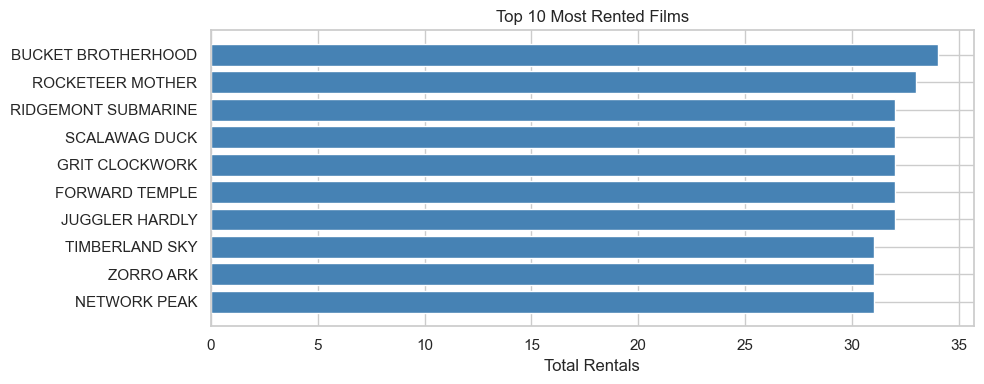

In [15]:
query1 = '''
SELECT
    f.title,
    f.category_name,
    f.rating,
    SUM(fr.rental_count) AS total_rentals
FROM fact_rental fr
JOIN dim_film f ON fr.film_key = f.film_key
GROUP BY f.title, f.category_name, f.rating
ORDER BY total_rentals DESC
LIMIT 10;
'''
df1 = pd.read_sql(query1, dw_engine)
print("=== Q1: Top 10 Most Rented Films ===")
display(df1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(df1['title'][::-1], df1['total_rentals'][::-1], color='steelblue')
ax.set_title('Top 10 Most Rented Films')
ax.set_xlabel('Total Rentals')
plt.tight_layout()
plt.show()

### Q2 — Revenue by Store
**Business question:** Which stores generate the highest revenue?

In [16]:
query2 = '''
SELECT
    s.store_id,
    s.manager_name,
    SUM(fp.payment_amount)     AS total_revenue,
    COUNT(fp.payment_fact_key) AS total_payments
FROM fact_payment fp
JOIN dim_store s ON fp.store_key = s.store_key
GROUP BY s.store_id, s.manager_name
ORDER BY total_revenue DESC;
'''
df2 = pd.read_sql(query2, dw_engine)
print("=== Q2: Revenue by Store ===")
display(df2)



=== Q2: Revenue by Store ===


,store_id,manager_name,total_revenue,total_payments
0,2,Jon Stephens,33726.77,8121
1,1,Mike Hillyer,33679.79,7923


### Q3 — Top 10 Customers by Total Spending
**Business question:** Which customers generate the highest revenue?

=== Q3: Top 10 Customers by Spending ===


,full_name,email,total_spent,total_payments
0,KARL SEAL,KARL.SEAL@sakilacustomer.org,221.55,45
1,ELEANOR HUNT,ELEANOR.HUNT@sakilacustomer.org,216.54,46
2,CLARA SHAW,CLARA.SHAW@sakilacustomer.org,195.58,42
3,RHONDA KENNEDY,RHONDA.KENNEDY@sakilacustomer.org,194.61,39
4,MARION SNYDER,MARION.SNYDER@sakilacustomer.org,194.61,39
5,TOMMY COLLAZO,TOMMY.COLLAZO@sakilacustomer.org,186.62,38
6,WESLEY BULL,WESLEY.BULL@sakilacustomer.org,177.60,40
7,TIM CARY,TIM.CARY@sakilacustomer.org,175.61,39
8,MARCIA DEAN,MARCIA.DEAN@sakilacustomer.org,175.58,42
9,ANA BRADLEY,ANA.BRADLEY@sakilacustomer.org,174.66,34


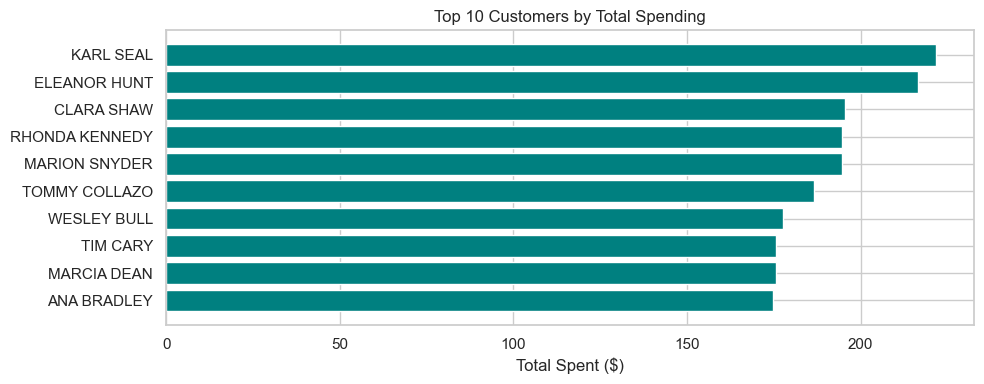

In [17]:
query3 = '''
SELECT
    c.full_name,
    c.email,
    SUM(fp.payment_amount)     AS total_spent,
    COUNT(fp.payment_fact_key) AS total_payments
FROM fact_payment fp
JOIN dim_customer c ON fp.customer_key = c.customer_key
GROUP BY c.full_name, c.email
ORDER BY total_spent DESC
LIMIT 10;
'''
df3 = pd.read_sql(query3, dw_engine)
print("=== Q3: Top 10 Customers by Spending ===")
display(df3)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(df3['full_name'][::-1], df3['total_spent'][::-1], color='teal')
ax.set_title('Top 10 Customers by Total Spending')
ax.set_xlabel('Total Spent ($)')
plt.tight_layout()
plt.show()

### Q4 — Monthly Revenue Trend
**Business question:** How does revenue change by month and year?

=== Q4: Monthly Revenue Trend ===


,year,month,month_name,total_revenue,total_payments
0,2005,5,May,4823.44,1156
1,2005,6,June,9629.89,2311
2,2005,7,July,28368.91,6709
3,2005,8,August,24070.14,5686
4,2006,2,February,514.18,182


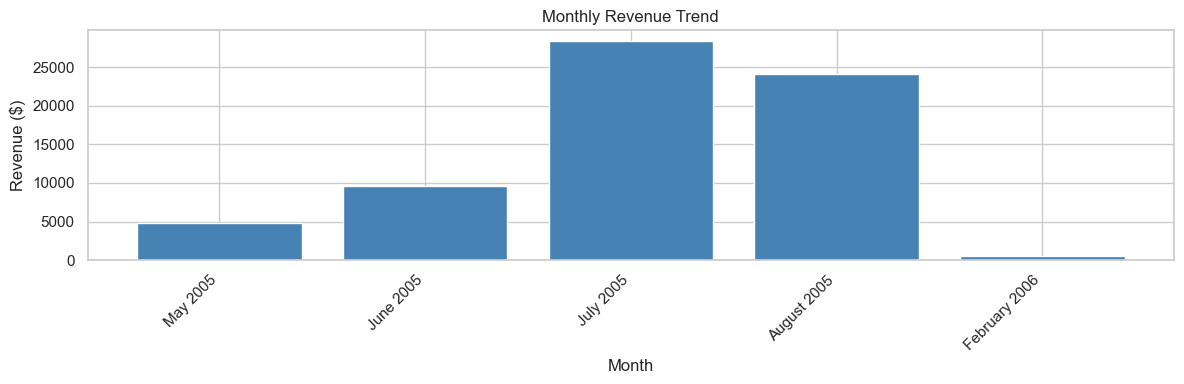

In [18]:
query4 = '''
SELECT
    d.year,
    d.month,
    d.month_name,
    SUM(fp.payment_amount)     AS total_revenue,
    COUNT(fp.payment_fact_key) AS total_payments
FROM fact_payment fp
JOIN dim_date d ON fp.payment_date_key = d.date_key
GROUP BY d.year, d.month, d.month_name
ORDER BY d.year, d.month;
'''
df4 = pd.read_sql(query4, dw_engine)
print("=== Q4: Monthly Revenue Trend ===")
display(df4)

fig, ax = plt.subplots(figsize=(12, 4))
labels = df4['month_name'] + ' ' + df4['year'].astype(str)
ax.bar(labels, df4['total_revenue'], color='steelblue')
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Q5 — Top 10 Films with Most Late Returns
**Business question:** Which films are returned late most often?

In [19]:
query5 = '''
SELECT
    f.title,
    f.category_name,
    COUNT(*)                  AS late_return_count,
    AVG(fr.late_return_days)  AS avg_late_days
FROM fact_rental fr
JOIN dim_film f ON fr.film_key = f.film_key
WHERE fr.late_return_days > 0
GROUP BY f.title, f.category_name
ORDER BY late_return_count DESC
LIMIT 10;
'''
df5 = pd.read_sql(query5, dw_engine)
df5['avg_late_days'] = df5['avg_late_days'].round(2)
print("=== Q5: Top 10 Films with Most Late Returns ===")
display(df5)

=== Q5: Top 10 Films with Most Late Returns ===


,title,category_name,late_return_count,avg_late_days
0,RIDGEMONT SUBMARINE,New,24,3.62
1,BUTTERFLY CHOCOLAT,New,23,3.35
2,TELEGRAPH VOYAGE,Music,22,3.77
3,TIMBERLAND SKY,Classics,21,3.90
4,CHANCE RESURRECTION,Sports,20,2.45
5,GRIT CLOCKWORK,Games,20,3.40
6,ROCKETEER MOTHER,Foreign,20,3.75
7,ENGLISH BULWORTH,Sci-Fi,20,3.05
8,SATURDAY LAMBS,Sports,19,2.84
9,PRINCESS GIANT,Documentary,19,2.95


### Q6 — Top 10 Cities by Rental Activity
**Business question:** Which cities generate the most rental activity?

=== Q6: Top 10 Cities by Rental Activity ===


,city,country,total_rentals
0,Aurora,United States,50.0
1,London,United Kingdom,48.0
2,Saint-Denis,Réunion,46.0
3,Cape Coral,United States,45.0
4,Tanza,Philippines,42.0
5,Molodetšno,Belarus,42.0
6,Changhwa,Taiwan,41.0
7,Changzhou,China,40.0
8,Ourense (Orense),Spain,40.0
9,Bijapur,India,39.0


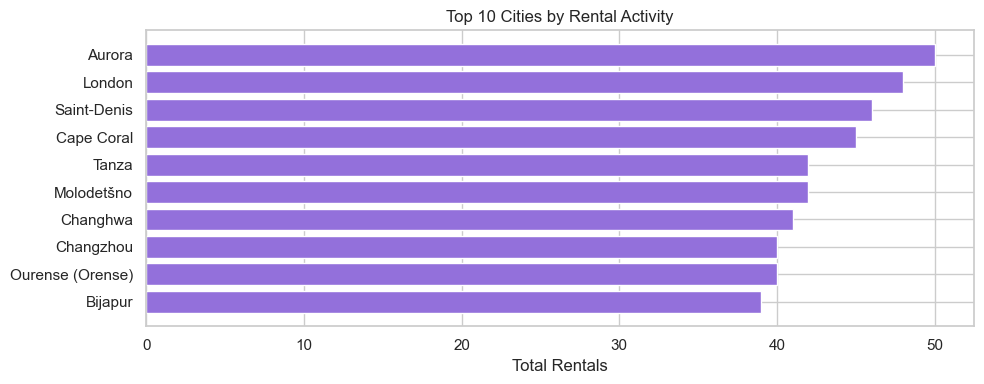

In [20]:
query6 = '''
SELECT
    l.city,
    l.country,
    SUM(fr.rental_count) AS total_rentals
FROM fact_rental fr
JOIN dim_location l ON fr.location_key = l.location_key
GROUP BY l.city, l.country
ORDER BY total_rentals DESC
LIMIT 10;
'''
df6 = pd.read_sql(query6, dw_engine)
print("=== Q6: Top 10 Cities by Rental Activity ===")
display(df6)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(df6['city'][::-1], df6['total_rentals'][::-1], color='mediumpurple')
ax.set_title('Top 10 Cities by Rental Activity')
ax.set_xlabel('Total Rentals')
plt.tight_layout()
plt.show()

### Q7 — Staff Revenue Performance
**Business question:** Which staff members process the most revenue?

In [21]:
query7 = '''
SELECT
    s.full_name,
    s.email,
    SUM(fp.payment_amount)     AS total_revenue,
    COUNT(fp.payment_fact_key) AS total_payments
FROM fact_payment fp
JOIN dim_staff s ON fp.staff_key = s.staff_key
GROUP BY s.full_name, s.email
ORDER BY total_revenue DESC;
'''
df7 = pd.read_sql(query7, dw_engine)
print("=== Q7: Staff Revenue Performance ===")
display(df7)



=== Q7: Staff Revenue Performance ===


,full_name,email,total_revenue,total_payments
0,Jon Stephens,Jon.Stephens@sakilastaff.com,33924.06,7990
1,Mike Hillyer,Mike.Hillyer@sakilastaff.com,33482.50,8054


### Q8 — Most Popular Film Categories
**Business question:** Which film categories are rented the most?

In [22]:
query8 = '''
SELECT
    f.category_name,
    SUM(fr.rental_count) AS total_rentals
FROM fact_rental fr
JOIN dim_film f ON fr.film_key = f.film_key
GROUP BY f.category_name
ORDER BY total_rentals DESC
LIMIT 15;
'''
df8 = pd.read_sql(query8, dw_engine)
print("=== Q8: Most Popular Film Categories ===")
display(df8)



=== Q8: Most Popular Film Categories ===


,category_name,total_rentals
0,Sports,1179.0
1,Animation,1166.0
2,Action,1112.0
3,Sci-Fi,1101.0
4,Family,1096.0
5,Drama,1060.0
6,Documentary,1050.0
7,Foreign,1033.0
8,Games,969.0
9,Children,945.0


### Q9 — Average Rental Duration by Film Rating
**Business question:** What is the average rental duration for different film ratings?

In [23]:
query9 = '''
SELECT
    f.rating,
    COUNT(fr.rental_fact_key)  AS total_rentals,
    AVG(fr.rental_duration)    AS avg_duration_days,
    MAX(fr.rental_duration)    AS max_duration_days
FROM fact_rental fr
JOIN dim_film f ON fr.film_key = f.film_key
WHERE fr.rental_duration > 0
GROUP BY f.rating
ORDER BY avg_duration_days DESC;
'''
df9 = pd.read_sql(query9, dw_engine)
df9['avg_duration_days'] = df9['avg_duration_days'].round(2)
print("=== Q9: Average Rental Duration by Film Rating ===")
display(df9)



=== Q9: Average Rental Duration by Film Rating ===


,rating,total_rentals,avg_duration_days,max_duration_days
0,PG-13,3350,4.84,9
1,G,2598,4.80,9
2,NC-17,3079,4.78,9
3,PG,3005,4.74,9
4,R,2983,4.74,9


### Q10 — Top 10 Films by Revenue
**Business question:** Which films generate the highest revenue?

In [24]:
query10 = '''
SELECT
    f.title,
    f.category_name,
    f.rating,
    SUM(fp.payment_amount)     AS total_revenue,
    COUNT(fp.payment_fact_key) AS total_payments
FROM fact_payment fp
JOIN dim_film f ON fp.film_key = f.film_key
GROUP BY f.title, f.category_name, f.rating
ORDER BY total_revenue DESC
LIMIT 10;
'''
df10 = pd.read_sql(query10, dw_engine)
print("=== Q10: Top 10 Films by Revenue ===")
display(df10)



=== Q10: Top 10 Films by Revenue ===


,title,category_name,rating,total_revenue,total_payments
0,TELEGRAPH VOYAGE,Music,PG,231.73,27
1,WIFE TURN,Documentary,NC-17,223.69,31
2,ZORRO ARK,Comedy,NC-17,214.69,31
3,GOODFELLAS SALUTE,Sci-Fi,PG,209.69,31
4,SATURDAY LAMBS,Sports,G,204.72,28
5,TITANS JERK,Sci-Fi,PG,201.71,29
6,TORQUE BOUND,Drama,G,198.72,27
7,HARRY IDAHO,Drama,PG-13,195.70,30
8,INNOCENT USUAL,Foreign,PG-13,191.74,26
9,HUSTLER PARTY,Comedy,NC-17,190.78,22
